In [1]:
using PlotlyJS
using Infiltrator
using XLSX
include("../model/pre_processing.jl")

# include("../../utils/main.jl")


generate_energy_reserves_cumulative (generic function with 1 method)

In [2]:
function load_deterministic_data(day, input_folder, ε=nothing, ρ=nothing)
    gen_df, loads_multi_df, gen_variable_multi_df, storage_df, random_loads_multi_df = generate_input_data(day, input_folder)
    # required_reserve = generate_reserves(loads_multi_df, gen_variable_multi_df, reserve)
    file = joinpath(input_folder, G_UC_DATA, "Reserve.csv")
    if isfile(file)
        println("Reserve file found, loading reserves...")                            
        required_reserve = filter_day(day, CSV.read(file, DataFrame))
    else
        println("Reserve file not found, generating reserves...")
        required_reserve = generate_reserves(loads_multi_df, gen_variable_multi_df, ε, ρ)
    end
    random_loads_multi_df = filter_demand(loads_multi_df, random_loads_multi_df, required_reserve)
    return gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve
end

function load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
    file = joinpath(input_folder, G_UC_DATA, "Energy reserve.csv")
    if isfile(file)
        println("Energy reserve file found, loading reserves...")
        return filter_day(day, CSV.read(file, DataFrame))
    else
        println("Energy reserve file not found, generating reserves...")
        return  generate_energy_reserves(loads_multi_df, gen_variable_multi_df, ε, ρ)
    end
end

load_energy_reserve (generic function with 1 method)

In [3]:
day = 7
input_folder = "../input/base_case_increased_storage_energy_v7.0.8.0"
ε = 0.025
ρ = 0.8
gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
;

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...


In [4]:
include("../model/utils/empirical_mu.jl")
out = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve)
out2 = Dict(key => unstack(out[key], :t, :value) for key in keys(out))   
out3 = reduce((df1, df2) -> outerjoin(df1, df2, on=[:r_id,:t]), [rename(out[key], :value => key) for key in keys(out)])
out3_sum = combine(groupby(out3, :t), Not([:r_id, :t]) .=> sum, renamecols = false)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 42448 rows, 29320 columns and 113080 nonzeros
Model fingerprint: 0x8240f7a8
Model has 960 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 3e+03]
Presolve removed 21567 rows and 13660 columns
Presolve time: 0.10s
Presolved: 20881 rows, 15660 columns, 78166 nonzeros
Presolved model

Row,t,RESUPCH,RESDNDIS,θUPDIS,RESDNCH,RESUPDIS,θDNDIS,θDNCH,θUPCH
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,145,3.51739e-13,158.496,137.839,-2.72848e-12,137.839,158.496,2.67105e-13,3.44394e-13
2,146,2.31127,179.96,148.705,7.51347,149.44,177.017,1.2199e-5,1.20991e-5
3,147,2.26242,151.066,116.064,3.37668,116.875,147.665,4.68255e-7,4.6862e-7
4,148,8.08801,163.267,136.012,8.77602,140.221,159.004,2.51182e-7,2.42286e-7
5,149,9.3411,177.798,138.264,5.06535,142.899,172.854,1.46892e-7,1.46021e-7
6,150,10.1889,145.143,160.195,10.7595,165.414,139.653,1.01617e-7,1.00513e-7
7,151,12.176,209.756,177.381,6.18448,183.286,203.474,7.69606e-8,7.6398e-8
8,152,13.5357,201.294,181.297,13.8696,188.155,194.294,6.09914e-8,6.05438e-8
9,153,16.6148,153.878,138.82,7.87399,146.701,145.839,4.96283e-8,4.92883e-8


In [5]:
# keys_out3_sum = setdiff(Symbol.(names(out3_sum)), [:r_id, :t])
# p1 = plot(stack(out3_sum, keys_out3_sum), x = :t, y = :value, color =:variable)

┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


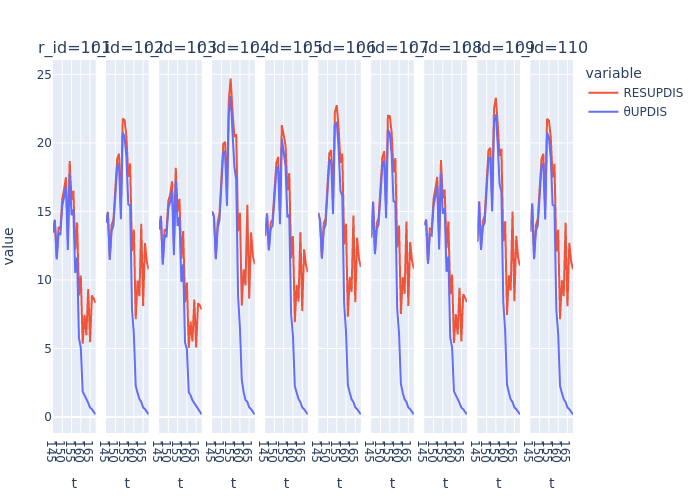

In [6]:
ks = [:θUPDIS,:RESUPDIS]
p1 = plot(stack(out3, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


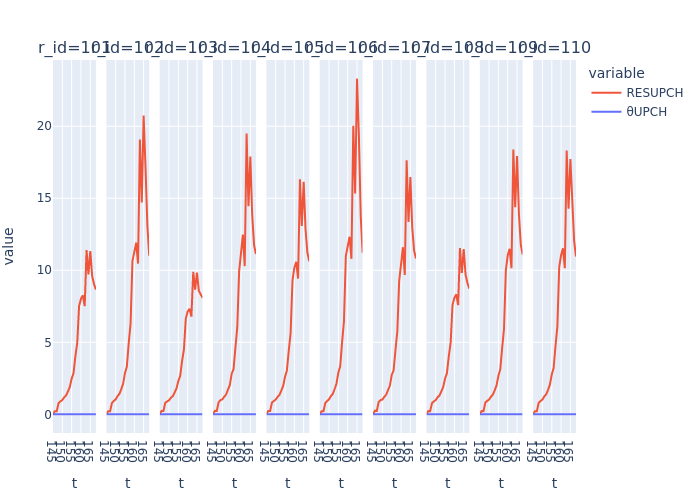

In [7]:
ks = [:θUPCH,:RESUPCH]
p1 = plot(stack(out3, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


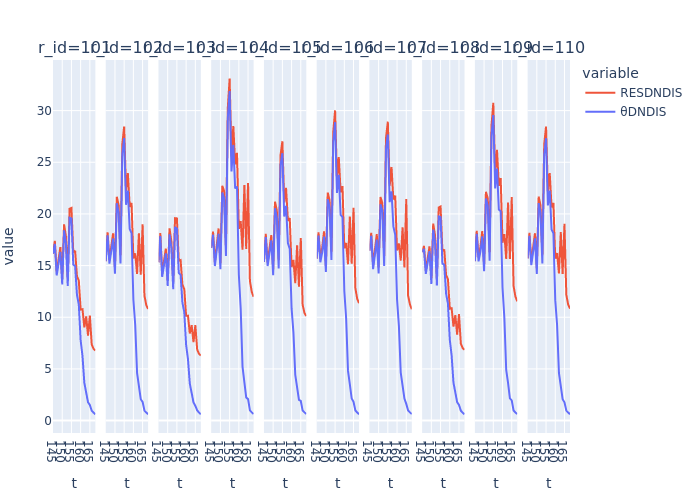

In [8]:
ks = [:θDNDIS,:RESDNDIS]
p1 = plot(stack(out3, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


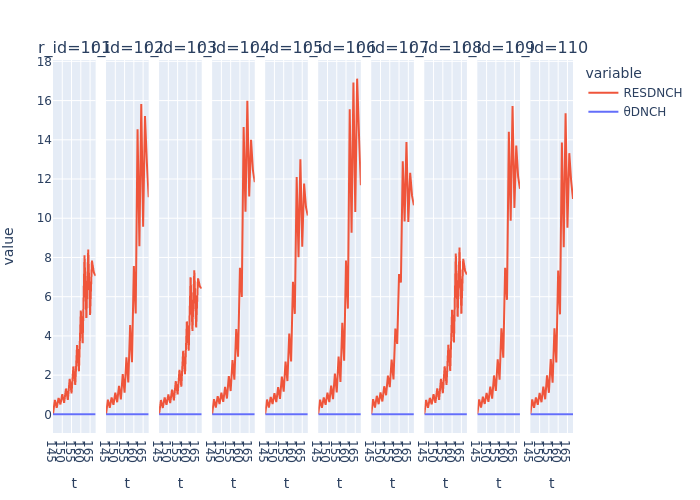

In [9]:
ks = [:θDNCH,:RESDNCH]
p1 = plot(stack(out3, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

In [10]:
mu = []
aux = out2[:θUPDIS] ./ out2[:RESUPDIS]
push!(mu, maximum(aux[:,names(aux)[end]]))

aux = out2[:θUPCH] ./ out2[:RESUPCH]
push!(mu, maximum(aux[:,names(aux)[end]]))

aux = out2[:θDNDIS] ./ out2[:RESDNDIS]
push!(mu, maximum(aux[:,names(aux)[end]]))

# aux = out2[:θDNCH] ./ out2[:RESDNCH]
# push!(mu, maximum(aux[:,names(aux)[end]]))

maximum(mu)


0.09602512412298504

In [11]:
-- XLSX.openxlsx("output.xlsx", mode="w") do xf
--     for key in keys(out2)
--         sheet = XLSX.addsheet!(xf, string(key))
--         XLSX.writetable!(sheet, out2[key])
--     end
-- end

Base.Meta.ParseError: ParseError:
# Error @ /mnt/c/Users/pgallego/OneDrive - Imperial College London/PhD/Repositories/energy_reserve/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sdnNjb2RlLXJlbW90ZQ==.jl:1:1
-- XLSX.openxlsx("output.xlsx", mode="w") do xf
└┘ ── not a unary operator